# 🌲 Random Forest Classifier

The direct fix for the previous notebook's discovery: a single decision tree is **unstable** — small data changes shift its structure. Random Forest's answer is almost embarrassingly simple: train *many* trees on randomized variations of the data, and average their votes. The instability doesn't go away in any one tree, but it cancels out across many.

📖 Full mathematical explanation (bootstrap sampling, bagging variance reduction, OOB score derivation): [README.md](README.md)


## 1. Setup & Recap

Same 2D synthetic dataset and Breast Cancer dataset as the Decision Tree notebook, so results are directly comparable.


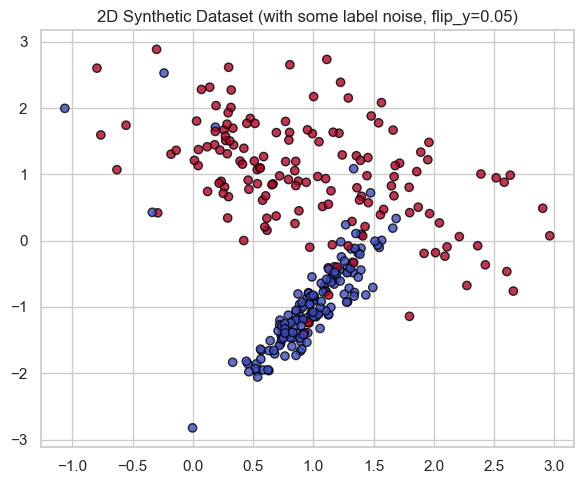

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
np.random.seed(42)

X_2d, y_2d = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.0, flip_y=0.05, random_state=42
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.8)
ax.set_title("2D Synthetic Dataset (with some label noise, flip_y=0.05)")
plt.tight_layout()
plt.show()


## 2. Bootstrap Sampling

A **bootstrap sample** draws $n$ examples from the training set *with replacement* — some points appear multiple times, others not at all. Each tree in the forest trains on a different bootstrap sample, giving each one a slightly different view of the same underlying data.


In [2]:
np.random.seed(1)
original_data = np.arange(10)
bootstrap_sample = np.random.choice(original_data, size=10, replace=True)

print("Original data:   ", original_data)
print("Bootstrap sample: ", bootstrap_sample)
print("Unique points included:", len(np.unique(bootstrap_sample)), "out of 10")
print("\n-> On average, a bootstrap sample includes about 63.2% of the unique original points")
print("   (the rest are duplicates) -- the remaining ~36.8% are the 'out-of-bag' points, used in section 8.")


Original data:    [0 1 2 3 4 5 6 7 8 9]
Bootstrap sample:  [5 8 9 5 0 0 1 7 6 9]
Unique points included: 7 out of 10

-> On average, a bootstrap sample includes about 63.2% of the unique original points
   (the rest are duplicates) -- the remaining ~36.8% are the 'out-of-bag' points, used in section 8.


## 3. Bagging From Scratch — Many Trees, Averaged

**Bagging** (Bootstrap AGGregatING): train $B$ independent trees, each on its own bootstrap sample, then combine their predictions by majority vote. This alone (before adding random feature selection) already reduces variance substantially.


In [3]:
def train_bagged_trees(X, y, n_trees=20, max_depth=None, random_state=42):
    rng = np.random.RandomState(random_state)
    trees = []
    for i in range(n_trees):
        bootstrap_idx = rng.choice(len(X), size=len(X), replace=True)
        tree = DecisionTreeClassifier(max_depth=max_depth, random_state=rng.randint(10000))
        tree.fit(X[bootstrap_idx], y[bootstrap_idx])
        trees.append(tree)
    return trees

def predict_bagged(trees, X):
    all_preds = np.array([tree.predict(X) for tree in trees])   # shape: (n_trees, n_samples)
    return np.array([np.bincount(all_preds[:, i]).argmax() for i in range(all_preds.shape[1])])

bagged_trees = train_bagged_trees(X_2d, y_2d, n_trees=20)
bagged_preds = predict_bagged(bagged_trees, X_2d)
print("Bagged ensemble (20 trees) training accuracy:", round(accuracy_score(y_2d, bagged_preds), 4))


Bagged ensemble (20 trees) training accuracy: 0.9967


## 4. Variance Reduction — Single Tree vs Bagged Ensemble

The whole point of bagging: a single unconstrained tree overfits and varies wildly across resamples (previous notebook's §15); averaging many such trees should produce more *stable* test performance, even though each individual tree is still unstable.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_2d, y_2d, test_size=0.3, stratify=y_2d, random_state=42)

# Fair comparison: BOTH methods see a different bootstrap-resampled training set each trial --
# isolating exactly what averaging buys you, given the same underlying resampling instability.
single_tree_test_accs, bagged_test_accs = [], []
for seed in range(15):
    rng = np.random.RandomState(seed)
    boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_boot, y_boot = X_train[boot_idx], y_train[boot_idx]

    single_tree = DecisionTreeClassifier(random_state=seed).fit(X_boot, y_boot)
    single_tree_test_accs.append(accuracy_score(y_test, single_tree.predict(X_test)))

    trees = train_bagged_trees(X_train, y_train, n_trees=20, random_state=seed)   # bagging resamples internally, per tree
    bag_preds = predict_bagged(trees, X_test)
    bagged_test_accs.append(accuracy_score(y_test, bag_preds))

print(f"Single tree (each on a fresh bootstrap resample): mean={np.mean(single_tree_test_accs):.4f}, std={np.std(single_tree_test_accs):.4f}")
print(f"Bagged ensemble (20 trees, averaged):              mean={np.mean(bagged_test_accs):.4f}, std={np.std(bagged_test_accs):.4f}")
print("\n-> Lower std means more STABLE performance across different resamples --")
print("   the direct, measurable benefit of averaging many trees instead of trusting one.")


Single tree (each on a fresh bootstrap resample): mean=0.8874, std=0.0246
Bagged ensemble (20 trees, averaged):              mean=0.9200, std=0.0073

-> Lower std means more STABLE performance across different resamples --
   the direct, measurable benefit of averaging many trees instead of trusting one.


## 5. Random Feature Selection — the Second "Random" in Random Forest

Bagging alone still lets every tree consider every feature, so if one feature is very strong, most bootstrap trees end up looking similar (correlated) anyway. Random Forest adds a second randomization: at every split, only a random *subset* of features is even considered — forcing trees to diversify.


In [5]:
cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = cancer.data, cancer.target
n_features_total = X_cancer.shape[1]

# Default max_features for classification is sqrt(n_features) -- illustrate what that means concretely
default_max_features = int(np.sqrt(n_features_total))
print(f"Total features available: {n_features_total}")
print(f"Features considered per split (default 'sqrt'): {default_max_features}")
print("\n-> Each split only gets to 'see' a random subset of ~5-6 out of 30 features --")
print("   even a very strong feature won't dominate every tree's structure this way.")


Total features available: 30
Features considered per split (default 'sqrt'): 5

-> Each split only gets to 'see' a random subset of ~5-6 out of 30 features --
   even a very strong feature won't dominate every tree's structure this way.


## 6. Comparing Against scikit-learn's RandomForestClassifier

`RandomForestClassifier` implements both bagging (bootstrap samples) and random feature selection together. Verifying it substantially outperforms both a single tree and our from-scratch bagging-only ensemble (which lacks the feature-randomization step).


In [6]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancer, y_cancer, test_size=0.2, stratify=y_cancer, random_state=42)

single_tree_c = DecisionTreeClassifier(random_state=42).fit(X_train_c, y_train_c)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_c, y_train_c)

print(f"Single Decision Tree test accuracy: {accuracy_score(y_test_c, single_tree_c.predict(X_test_c)):.4f}")
print(f"Random Forest (100 trees) test accuracy: {accuracy_score(y_test_c, rf_model.predict(X_test_c)):.4f}")


Single Decision Tree test accuracy: 0.9123
Random Forest (100 trees) test accuracy: 0.9561


## 7. Effect of `n_estimators` — More Trees, More Stable

Adding more trees to the forest reduces prediction variance further, with diminishing returns — past a certain point, more trees cost more compute without meaningfully improving accuracy.


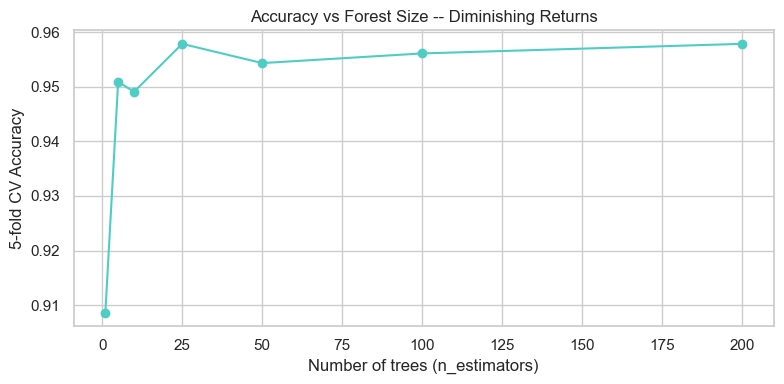

n_estimators=  1: CV accuracy = 0.9086
n_estimators=  5: CV accuracy = 0.9509
n_estimators= 10: CV accuracy = 0.9491
n_estimators= 25: CV accuracy = 0.9578
n_estimators= 50: CV accuracy = 0.9543
n_estimators=100: CV accuracy = 0.9561
n_estimators=200: CV accuracy = 0.9578


In [7]:
n_estimators_range = [1, 5, 10, 25, 50, 100, 200]
cv_scores = []

for n in n_estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(model, X_cancer, y_cancer, cv=5).mean()
    cv_scores.append(score)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimators_range, cv_scores, marker="o", color="#4ecdc4")
ax.set_xlabel("Number of trees (n_estimators)")
ax.set_ylabel("5-fold CV Accuracy")
ax.set_title("Accuracy vs Forest Size -- Diminishing Returns")
plt.tight_layout()
plt.show()

for n, s in zip(n_estimators_range, cv_scores):
    print(f"n_estimators={n:>3}: CV accuracy = {s:.4f}")


## 8. Out-of-Bag (OOB) Score — Free Validation

Since each tree only trains on ~63.2% of the data (section 2), the remaining ~36.8% ("out-of-bag" points) can be used to evaluate *that* tree, without needing a separate held-out validation set — a free, built-in cross-validation-like estimate.


In [8]:
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)
rf_oob.fit(X_train_c, y_train_c)

print(f"OOB score (estimated from unseen-per-tree data): {rf_oob.oob_score_:.4f}")
print(f"Actual held-out test accuracy:                    {accuracy_score(y_test_c, rf_oob.predict(X_test_c)):.4f}")
print("\n-> OOB score is computed WITHOUT touching the test set at all, yet closely tracks real test")
print("   performance -- useful when data is too limited to comfortably carve out a separate validation split.")


OOB score (estimated from unseen-per-tree data): 0.9604
Actual held-out test accuracy:                    0.9561

-> OOB score is computed WITHOUT touching the test set at all, yet closely tracks real test
   performance -- useful when data is too limited to comfortably carve out a separate validation split.


## 9. Feature Importance — More Stable Than a Single Tree's

Random Forest feature importance averages each feature's impurity-decrease contribution *across all trees* — directly addressing the previous notebook's finding that a single tree's importance ranking can shift with small data changes.


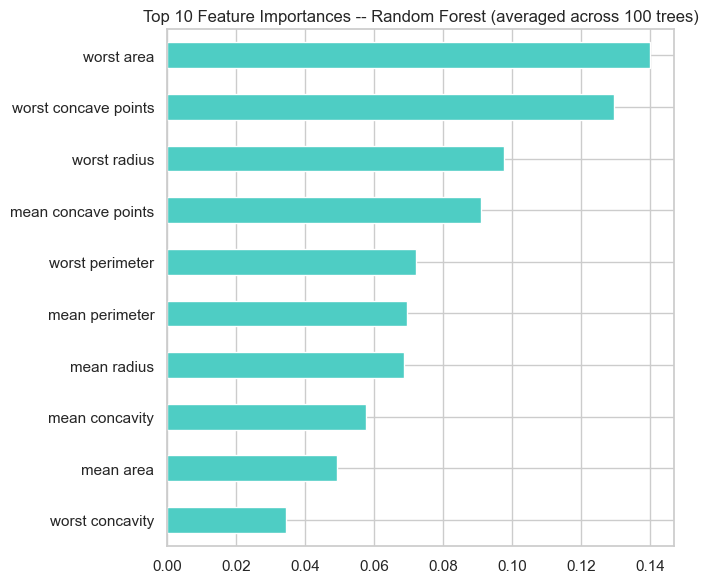

worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
dtype: float64


In [9]:
importance = pd.Series(rf_model.feature_importances_, index=cancer.feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
importance.head(10).plot(kind="barh", ax=ax, color="#4ecdc4")
ax.set_title("Top 10 Feature Importances -- Random Forest (averaged across 100 trees)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.head(10))


## 10. Importance Stability — Random Forest vs Single Tree

Directly re-running the previous notebook's bootstrap-instability experiment, but for Random Forest's *averaged* importance instead of a single tree's — the ranking should now be far more consistent across resamples.


In [10]:
top_features_per_trial = []
for trial in range(5):
    bootstrap_idx = np.random.RandomState(trial).choice(len(X_cancer), size=len(X_cancer), replace=True)
    X_boot, y_boot = X_cancer.values[bootstrap_idx], y_cancer.values[bootstrap_idx]
    model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_boot, y_boot)
    top_feature = cancer.feature_names[np.argmax(model.feature_importances_)]
    top_features_per_trial.append(top_feature)

print("Top feature across 5 bootstrap resamples (Random Forest):", top_features_per_trial)
print(f"Unique top features: {len(set(top_features_per_trial))} (compare to 3 unique ROOT features for a single tree)")


Top feature across 5 bootstrap resamples (Random Forest): [np.str_('worst area'), np.str_('worst area'), np.str_('worst area'), np.str_('worst area'), np.str_('worst area')]
Unique top features: 1 (compare to 3 unique ROOT features for a single tree)


## 11. Decision Boundary — Smoother Than a Single Tree

Averaging many axis-aligned "staircase" trees produces a boundary that's still ultimately made of small rectangular regions, but far smoother in aggregate than any single tree's blocky boundary.


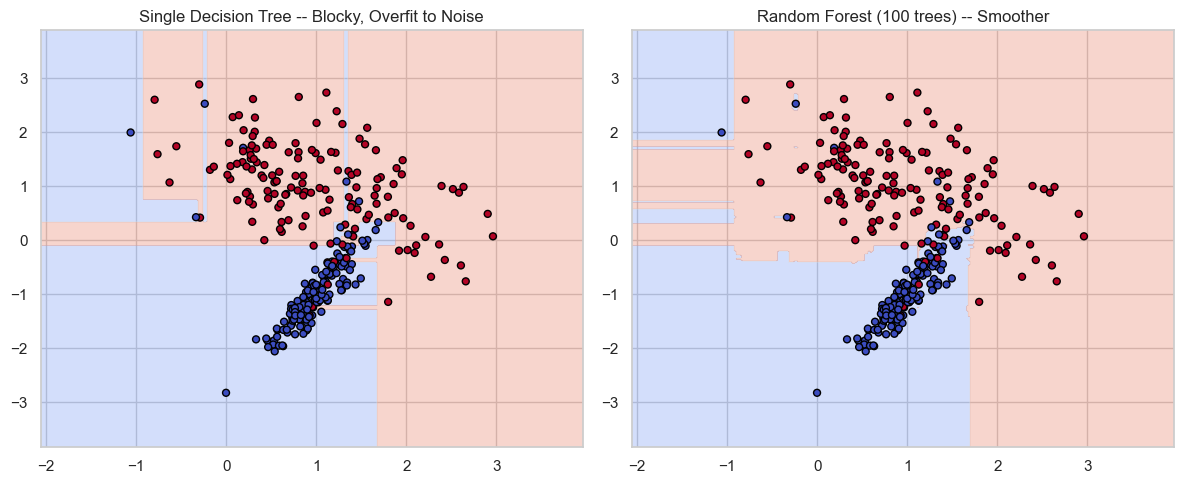

In [11]:
def plot_boundary(ax, model, X, y, title):
    x1_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
    x2_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    xx1, xx2 = np.meshgrid(x1_range, x2_range)
    preds = model.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
    ax.contourf(xx1, xx2, preds, levels=2, cmap="coolwarm", alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=25)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
single = DecisionTreeClassifier(random_state=42).fit(X_2d, y_2d)
forest = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_2d, y_2d)
plot_boundary(axes[0], single, X_2d, y_2d, "Single Decision Tree -- Blocky, Overfit to Noise")
plot_boundary(axes[1], forest, X_2d, y_2d, "Random Forest (100 trees) -- Smoother")
plt.tight_layout()
plt.show()


## 12. Overfitting Comparison — Random Forest vs Single Tree

At matched (unlimited) depth, does Random Forest still overfit as badly as a single tree? Comparing train/test accuracy gaps directly answers this.


In [12]:
single_deep = DecisionTreeClassifier(random_state=42).fit(X_train_c, y_train_c)
forest_deep = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_c, y_train_c)

print("Single Tree  -- train:", round(accuracy_score(y_train_c, single_deep.predict(X_train_c)), 4),
      "| test:", round(accuracy_score(y_test_c, single_deep.predict(X_test_c)), 4))
print("Random Forest -- train:", round(accuracy_score(y_train_c, forest_deep.predict(X_train_c)), 4),
      "| test:", round(accuracy_score(y_test_c, forest_deep.predict(X_test_c)), 4))
print("\n-> Both fit training data almost perfectly, but the Random Forest's train-test GAP is typically")
print("   smaller -- averaging reduces overfitting's real-world cost even without limiting individual tree depth.")


Single Tree  -- train: 1.0 | test: 0.9123
Random Forest -- train: 1.0 | test: 0.9561

-> Both fit training data almost perfectly, but the Random Forest's train-test GAP is typically
   smaller -- averaging reduces overfitting's real-world cost even without limiting individual tree depth.


## 13. Hyperparameter Sweep — `max_features`

`max_features` controls how many features are randomly considered per split (section 5). Too few loses useful signal per split; too many (all features) degrades back toward correlated, bagging-only trees.


In [13]:
max_features_options = ["sqrt", "log2", 0.5, None]
for mf in max_features_options:
    model = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=42)
    score = cross_val_score(model, X_cancer, y_cancer, cv=5).mean()
    print(f"max_features={str(mf):6s} -> CV accuracy: {score:.4f}")


max_features=sqrt   -> CV accuracy: 0.9561


max_features=log2   -> CV accuracy: 0.9596


max_features=0.5    -> CV accuracy: 0.9631


max_features=None   -> CV accuracy: 0.9561


## 14. Final Evaluation — Breast Cancer Dataset

Full classification report and confusion matrix for the tuned Random Forest, directly comparable to the Decision Tree notebook's equivalent results.


OOB score:      0.9604
Test accuracy:  0.9561

               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



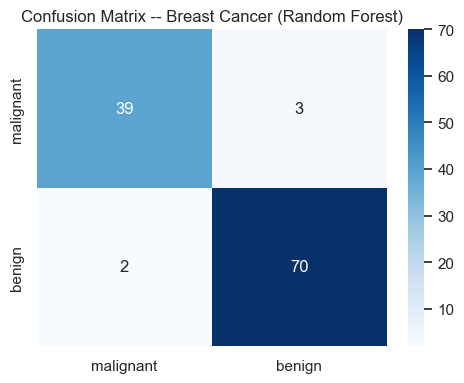

In [14]:
final_rf = RandomForestClassifier(n_estimators=200, max_features="sqrt", random_state=42, oob_score=True)
final_rf.fit(X_train_c, y_train_c)
final_preds = final_rf.predict(X_test_c)

print(f"OOB score:      {final_rf.oob_score_:.4f}")
print(f"Test accuracy:  {accuracy_score(y_test_c, final_preds):.4f}")
print("\n", classification_report(y_test_c, final_preds, target_names=cancer.target_names))

cm = confusion_matrix(y_test_c, final_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
ax.set_title("Confusion Matrix -- Breast Cancer (Random Forest)")
plt.tight_layout()
plt.show()


## 15. Handling Class Imbalance — `class_weight`

Random Forest supports the exact same `class_weight="balanced"` mechanism from Foundation's Preprocessing notebook, applied per-tree during the impurity calculation — misclassifying a minority-class sample costs more, biasing every tree's splits toward respecting it.


In [15]:
X_imb, y_imb = make_classification(
    n_samples=400, n_features=10, n_informative=5, weights=[0.9, 0.1],
    class_sep=0.8, random_state=7
)
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=42)

rf_unweighted = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_imb_train, y_imb_train)
rf_weighted = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42).fit(X_imb_train, y_imb_train)

def minority_recall(model, X, y):
    preds = model.predict(X)
    return ((preds == 1) & (y == 1)).sum() / (y == 1).sum()

print(f"Minority-class recall, unweighted: {minority_recall(rf_unweighted, X_imb_test, y_imb_test):.3f}")
print(f"Minority-class recall, class_weight='balanced': {minority_recall(rf_weighted, X_imb_test, y_imb_test):.3f}")


Minority-class recall, unweighted: 0.154
Minority-class recall, class_weight='balanced': 0.385


## ✅ Key Takeaways

- Random Forest fixes the previous notebook's core weakness — **instability** — not by making any single tree more stable, but by averaging many independently-unstable trees so their errors partially cancel out.
- Two sources of randomness matter: **bootstrap sampling** (bagging, different rows per tree) and **random feature subsets** (different columns considered per split) — both are needed to properly decorrelate the trees.
- **OOB score** provides a free, built-in validation estimate using each tree's ~36.8% unseen bootstrap data — useful when held-out data is scarce.
- More trees (`n_estimators`) almost always helps, with diminishing returns — there's rarely a reason to use fewer than 100 in practice, compute budget permitting.
- Feature importance is far more *stable* across resamples for a forest than for a single tree — directly fixing the instability demonstrated in the previous notebook.
- The accuracy/interpretability tradeoff is real: Random Forest usually beats a single tree, but you lose the "read the exact rules" transparency that made a single tree appealing in the first place.

**Next up:** [06_SVM_Classification](../06_SVM_Classification/) — a maximum-margin approach with the kernel trick, capable of learning non-linear boundaries a completely different way.
